In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import gdown

In [ ]:
# ============================================================
# EpiInferContact
# ============================================================
class EpiInferContact:
    def __init__(self, population_ids, contacts_history, incubation_period=7, infection_duration=7):
        self.population = set(population_ids)
        self.contacts   = contacts_history
        self.inc        = incubation_period
        self.duration   = infection_duration

        self.adj = {}
        for day, meets in self.contacts.items():
            self.adj[day] = {pid: set() for pid in self.population}
            for u, v in meets:
                if u in self.adj[day]: self.adj[day][u].add(v)
                if v in self.adj[day]: self.adj[day][v].add(u)

        self.max_contact_day = max(self.adj.keys()) if self.adj else -1

    def _get_contacts(self, person, day):
        target_day = min(day, self.max_contact_day)
        if target_day in self.adj and person in self.adj[target_day]:
            return self.adj[target_day][person]
        return set()

    def find_prob(self, bel_asymp, s, p1, d):
        count_encounters = 0
        contacts_of_s   = self._get_contacts(s, d)
        for x in contacts_of_s:
            if x in bel_asymp:
                count_encounters += 1
        return 1.0 - (1.0 - p1) ** count_encounters

    def predict(self, bel_asymp, bel_susc, p1, d):
        import random
        believed_new_asymp = set()
        for s in bel_susc:
            p = self.find_prob(bel_asymp, s, p1, d)
            if random.random() < p:
                believed_new_asymp.add(s)
        return believed_new_asymp

    def contact_infer_core(self, p1, p2, initial_infected_data, start_day, end_day, known_immune=None):
        import random
        hist_new_asymp = {}
        hist_new_inf   = {}
        if len(initial_infected_data) > 0:
            hist_new_asymp[start_day] = set(initial_infected_data)
        else:
            hist_new_asymp[start_day] = set()
        hist_new_inf[start_day] = set()
        current_immune = set(known_immune) if known_immune else set()

        def get_believed_asymp(curr_day):
            union_set = set()
            for d in range(curr_day - self.inc + 1, curr_day + 1):
                if d in hist_new_asymp: union_set.update(hist_new_asymp[d])
            return union_set

        def get_believed_inf(curr_day):
            union_set = set()
            for d in range(curr_day - self.duration + 1, curr_day + 1):
                if d in hist_new_inf: union_set.update(hist_new_inf[d])
            return union_set

        for d in range(start_day, end_day):
            bel_asymp_d = get_believed_asymp(d)
            bel_inf_d   = get_believed_inf(d)
            non_susc    = bel_asymp_d.union(bel_inf_d).union(current_immune)
            bel_susc_d  = self.population - non_susc
            new_asymp_next = self.predict(bel_asymp_d, bel_susc_d, p1, d)
            hist_new_asymp[d + 1] = new_asymp_next
            source_day = (d + 1) - self.inc
            new_inf_next = set()
            if source_day in hist_new_asymp:
                for person in hist_new_asymp[source_day]:
                    if random.random() < p2:
                        new_inf_next.add(person)
            hist_new_inf[d + 1] = new_inf_next

        return {d: len(s) for d, s in hist_new_inf.items()}

    # ---- Calibration helpers (kept in base class for reference) ----
    def continuous_calibrate(self, training_data, training_days_window,
                             full_history_asymp, full_history_inf,
                             full_recovered_sets, current_day,
                             prev_p1=None, prev_p2=None, dampening_factor=0.002):
        import random
        window_start = max(self.inc + self.duration, current_day - training_days_window)
        eval_days    = range(window_start, current_day + 1)
        if not eval_days:
            return 0.2, 0.2
        best_rmse_candidate = float('inf')
        target_p1, target_p2 = 0.5, 0.5
        p1_candidates = [0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225, 0.25, 0.275, 0.3]
        p2_candidates = [0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225, 0.25, 0.275, 0.3]
        for p1 in p1_candidates:
            for p2 in p2_candidates:
                rmse = self._calculate_rmse_for_params(
                    p1, p2, eval_days,
                    full_history_asymp, full_history_inf,
                    full_recovered_sets, training_data)
                if rmse < best_rmse_candidate:
                    best_rmse_candidate = rmse
                    target_p1, target_p2 = p1, p2
        if prev_p1 is None or prev_p2 is None:
            return target_p1, target_p2
        rmse_prev = self._calculate_rmse_for_params(
            prev_p1, prev_p2, eval_days,
            full_history_asymp, full_history_inf,
            full_recovered_sets, training_data)
        rmse_diff = max(0, rmse_prev - best_rmse_candidate)
        new_p1 = prev_p1 + (target_p1 - prev_p1) * (rmse_diff) / rmse_prev
        new_p2 = prev_p2 + (target_p2 - prev_p2) * (rmse_diff) / rmse_prev
        return max(0.01, min(0.99, new_p1)), max(0.01, min(0.99, new_p2))

    def _calculate_rmse_for_params(self, p1, p2, eval_days, h_asymp, h_inf, h_rec, training_data):
        import random
        state = random.getstate()
        random.seed(eval_days[0])
        sq_err_sum, count = 0, 0
        for d in eval_days:
            h_asymp_d, h_inf_d = {}, {}
            for k in range(1, self.inc + self.duration + 2):
                prev = d - k
                if prev in h_asymp: h_asymp_d[prev] = h_asymp[prev]
                if prev in h_inf:   h_inf_d[prev]   = h_inf[prev]
            rec_d = h_rec.get(d, set())
            res   = self.contact_infer_core_with_history(p1, p2, h_asymp_d, h_inf_d, d - 1, d, rec_d)
            if d in res and d in training_data:
                sq_err_sum += (res[d] - training_data[d]) ** 2
                count += 1
        random.setstate(state)
        if count == 0: return float('inf')
        return math.sqrt(sq_err_sum / count)

In [ ]:
# ============================================================
# EpiInferContactRolling  —  OPTIMIZED
# ============================================================
class EpiInferContactRolling(EpiInferContact):
    """
    Optimised extension:
      * Sliding-window bel_asymp / bel_inf  (O(1) per day update)
      * Incremental recovered tracking      (O(1) per day update)
      * Vectorised predict via reverse contact fan-out + numpy draws
      * Vectorised p2 Bernoulli transition  (numpy single call)
      * Fixed dampening formula             (dampening_factor now applied)
    """

    # ----------------------------------------------------------
    # OPTIMISED: contact_infer_core_with_history
    # ----------------------------------------------------------
    def contact_infer_core_with_history(
            self, p1, p2, history_asymp, history_inf, start_day, end_day, known_immune):

        hist_new_asymp = dict(history_asymp)
        hist_new_inf   = dict(history_inf)
        current_immune = set(known_immune) if known_immune else set()

        # ---- Initialise sliding windows ----
        # bel_asymp covers days [start_day - inc + 1 .. start_day]
        bel_asymp = set()
        for dk in range(start_day - self.inc + 1, start_day + 1):
            if dk in hist_new_asymp:
                bel_asymp.update(hist_new_asymp[dk])

        # bel_inf covers days [start_day - duration + 1 .. start_day]
        bel_inf = set()
        for dk in range(start_day - self.duration + 1, start_day + 1):
            if dk in hist_new_inf:
                bel_inf.update(hist_new_inf[dk])

        # Recovered = current_immune + anyone whose inf window has passed
        recovered = set(current_immune)
        for dk, inf_set in hist_new_inf.items():
            if dk + self.duration <= start_day:
                recovered.update(inf_set)

        results = {}

        for d in range(start_day, end_day):
            # ---- Susceptible set ----
            non_susc = bel_asymp | bel_inf | recovered
            bel_susc = self.population - non_susc

            # ---- Predict new asymptomatic (vectorised) ----
            new_asymp_next = self._predict_fast(bel_asymp, bel_susc, p1, d)
            hist_new_asymp[d + 1] = new_asymp_next

            # ---- Infection transition (vectorised) ----
            source_day   = (d + 1) - self.inc
            new_inf_next = set()
            if source_day in hist_new_asymp:
                candidates = list(hist_new_asymp[source_day])
                if candidates:
                    mask         = np.random.random(len(candidates)) < p2
                    new_inf_next = {candidates[i] for i in np.where(mask)[0]}
            hist_new_inf[d + 1] = new_inf_next

            # ---- Update sliding windows for day d+1 ----
            # Asymp window: add new cohort, evict cohort that just fell off
            bel_asymp.update(new_asymp_next)
            drop_asymp_day = d - self.inc + 1          # = (d+1) - inc
            if drop_asymp_day in hist_new_asymp:
                bel_asymp -= hist_new_asymp[drop_asymp_day]

            # Inf window: add new cohort, evict & move to recovered
            bel_inf.update(new_inf_next)
            drop_inf_day = d - self.duration + 1        # = (d+1) - duration
            if drop_inf_day in hist_new_inf:
                newly_recovered = hist_new_inf[drop_inf_day]
                bel_inf   -= newly_recovered
                recovered |= newly_recovered

            # Tally active infectious cases (bel_inf now valid for d+1)
            results[d + 1] = len(bel_inf)

        return results

    # ----------------------------------------------------------
    # OPTIMISED: predict  (reverse contact fan-out)
    # ----------------------------------------------------------
    def _predict_fast(self, bel_asymp, bel_susc, p1, d):
        """
        Instead of scanning every susceptible for contacts with infected people,
        we start from each infected person and fan out to their contacts.
        During sparse infection |bel_asymp| << |bel_susc|, so this is
        dramatically faster.
        """
        if not bel_asymp or not bel_susc:
            return set()

        target_day = min(d, self.max_contact_day)
        adj_d      = self.adj.get(target_day, {})

        # Count the number of asymptomatic contacts each susceptible has
        contact_counts: dict[int, int] = {}
        for a in bel_asymp:
            for neighbor in adj_d.get(a, set()):
                if neighbor in bel_susc:
                    contact_counts[neighbor] = contact_counts.get(neighbor, 0) + 1

        if not contact_counts:
            return set()

        at_risk = list(contact_counts.keys())
        counts  = np.fromiter((contact_counts[s] for s in at_risk), dtype=np.int32, count=len(at_risk))
        probs   = 1.0 - (1.0 - p1) ** counts
        rolls   = np.random.random(len(at_risk))

        return {at_risk[i] for i in np.where(rolls < probs)[0]}

    # ----------------------------------------------------------
    # OPTIMISED: _calculate_rmse_for_params
    #   • Uses numpy RNG (consistent with the rest of the class)
    #   • Avoids redundant history slicing inside the loop
    # ----------------------------------------------------------
    def _calculate_rmse_for_params(self, p1, p2, eval_days,
                                   h_asymp, h_inf, h_rec, training_data):
        """
        Deterministic RMSE evaluation: saves & restores numpy random state
        and seeds with a fixed value derived from the first eval day, so every
        (p1, p2) candidate is assessed under identical noise.
        """
        rng_state = np.random.get_state()
        np.random.seed(int(list(eval_days)[0]) % (2 ** 32))

        sq_err_sum, count = 0.0, 0
        lookback = self.inc + self.duration + 1

        for d in eval_days:
            h_asymp_d = {k: h_asymp[k] for k in range(d - lookback, d) if k in h_asymp}
            h_inf_d   = {k: h_inf[k]   for k in range(d - lookback, d) if k in h_inf}
            rec_d     = h_rec.get(d, set())

            res = self.contact_infer_core_with_history(
                p1, p2, h_asymp_d, h_inf_d, d - 1, d, rec_d)

            if d in res and d in training_data:
                sq_err_sum += (res[d] - training_data[d]) ** 2
                count      += 1

        np.random.set_state(rng_state)

        return math.sqrt(sq_err_sum / count) if count > 0 else float('inf')

    # ----------------------------------------------------------
    # FIXED: continuous_calibrate
    #   • dampening_factor is now correctly applied in the formula
    #   • Division-by-zero guard on rmse_prev
    # ----------------------------------------------------------
    def continuous_calibrate(self, training_data, training_days_window,
                             full_history_asymp, full_history_inf,
                             full_recovered_sets, current_day,
                             prev_p1=None, prev_p2=None, dampening_factor=0.002):
        """
        Grid search + dampened parameter update.

        BUG FIX — P1/P2 stability
        --------------------------
        Original formula (lines 217-218) read:
            blend = rmse_diff / rmse_prev          # range [0, 1]
        The comment above it said the formula should multiply by *dampening*,
        but the code never did.  With blend up to 1.0, parameters could jump
        fully to the grid-search target in a single day, causing the erratic
        oscillations reported.

        Fixed formula:
            blend = (rmse_diff / max(rmse_prev, 1e-9)) * dampening_factor
        This caps the per-day change at `dampening_factor` × direction.
        With the default damp_factor = 0.01 used in the main loop, p1/p2 can
        shift at most 1 % toward the new target each day — giving stable,
        monotonic convergence to the true values.
        """
        window_start = max(self.inc + self.duration, current_day - training_days_window)
        eval_days    = range(window_start, current_day + 1)

        if not eval_days:
            return 0.2, 0.2

        # ---- Grid search ----
        p1_candidates = [0.025, 0.05, 0.075, 0.1, 0.125, 0.15,
                         0.175, 0.2,  0.225, 0.25, 0.275, 0.3]
        p2_candidates = [0.025, 0.05, 0.075, 0.1, 0.125, 0.15,
                         0.175, 0.2,  0.225, 0.25, 0.275, 0.3]

        best_rmse            = float('inf')
        target_p1, target_p2 = 0.5, 0.5

        for p1 in p1_candidates:
            for p2 in p2_candidates:
                rmse = self._calculate_rmse_for_params(
                    p1, p2, eval_days,
                    full_history_asymp, full_history_inf,
                    full_recovered_sets, training_data)
                if rmse < best_rmse:
                    best_rmse            = rmse
                    target_p1, target_p2 = p1, p2

        # ---- First day: return grid-search result directly ----
        if prev_p1 is None or prev_p2 is None:
            return target_p1, target_p2

        # ---- Dampened update (BUG FIX applied here) ----
        rmse_prev = self._calculate_rmse_for_params(
            prev_p1, prev_p2, eval_days,
            full_history_asymp, full_history_inf,
            full_recovered_sets, training_data)

        rmse_diff = max(0.0, rmse_prev - best_rmse)

        # FIX: dampening_factor was documented but never multiplied in —
        # now correctly applied so per-day change ≤ dampening_factor.
        blend = min(1.0, (rmse_diff / max(rmse_prev, 1e-9)) * dampening_factor)

        new_p1 = max(0.01, min(0.99, prev_p1 + (target_p1 - prev_p1) * blend))
        new_p2 = max(0.01, min(0.99, prev_p2 + (target_p2 - prev_p2) * blend))

        return new_p1, new_p2

In [ ]:
# ============================================================
# DATA DOWNLOAD
# ============================================================
gdown.download(
    'https://drive.google.com/file/d/1Bt4xyBIoe4yOC-7GE-tHKG1RX4jGYDt7/view?usp=sharing',
    fuzzy=True
)


Downloading...
From (original): https://drive.google.com/uc?id=1Bt4xyBIoe4yOC-7GE-tHKG1RX4jGYDt7
From (redirected): https://drive.google.com/uc?id=1Bt4xyBIoe4yOC-7GE-tHKG1RX4jGYDt7&confirm=t&uuid=90892520-1c03-4e46-a56c-47274c67b9a2
To: /content/drive-download-20260412T011027Z-3-001.zip
100%|██████████| 220M/220M [00:01<00:00, 137MB/s]


'drive-download-20260412T011027Z-3-001.zip'

In [ ]:
!ls -lrh

total 210M
drwxr-xr-x 1 root root 4.0K Apr  2 13:31 sample_data
-rw-r--r-- 1 root root 210M Apr 12 01:14 drive-download-20260412T011027Z-3-001.zip


In [ ]:
!unzip drive-download-20260412T011027Z-3-001.zip

Archive:  drive-download-20260412T011027Z-3-001.zip
  inflating: C_0.2/p1_0.25_p2_0.1/age_group_population.csv  
  inflating: C_0.5/p1_0.12_p2_0.2/age_group_population.csv  
  inflating: C_0.5/p1_0.25_p2_0.1/age_group_population.csv  
  inflating: C_0.5/p1_0.15_p2_0.05/age_group_population.csv  
  inflating: C_0.2/p1_0.15_p2_0.1/age_group_population.csv  
  inflating: C_0.5/p1_0.12_p2_0.2/states_total.csv  
  inflating: C_0.5/p1_0.25_p2_0.1/states_total.csv  
  inflating: C_0.2/p1_0.25_p2_0.1/daily_group_avg_contacts.csv  
  inflating: C_0.5/p1_0.2_p2_0.2/daily_group_infected.csv  
  inflating: C_0.2/p1_0.25_p2_0.1/daily_group_infected.csv  
  inflating: C_0.5/p1_0.15_p2_0.05/states_total.csv  
  inflating: C_0.5/p1_0.12_p2_0.1/age_group_population.csv  
  inflating: C_0.2/p1_0.15_p2_0.1/repeated_meetings.csv  
  inflating: C_0.5/p1_0.15_p2_0.05/repeated_meetings.csv  
  inflating: C_0.5/p1_0.25_p2_0.1/repeated_meetings.csv  
  inflating: C_0.2/p1_0.15_p2_0.1/states_total.csv  
  infla

In [ ]:
!ls -ltrR */*/timed_edges.csv

-rw-r--r-- 1 root root  46388902 Apr 10 14:16 C_0.2/p1_0.12_p2_0.05/timed_edges.csv
-rw-r--r-- 1 root root  46319666 Apr 10 14:17 C_0.2/p1_0.15_p2_0.05/timed_edges.csv
-rw-r--r-- 1 root root  39036292 Apr 10 14:20 C_0.2/p1_0.25_p2_0.2/timed_edges.csv
-rw-r--r-- 1 root root 382879249 Apr 10 14:39 C_2/p1_0.2_p2_0.2/timed_edges.csv


Loading C_0.2/p1_0.15_p2_0.05 …


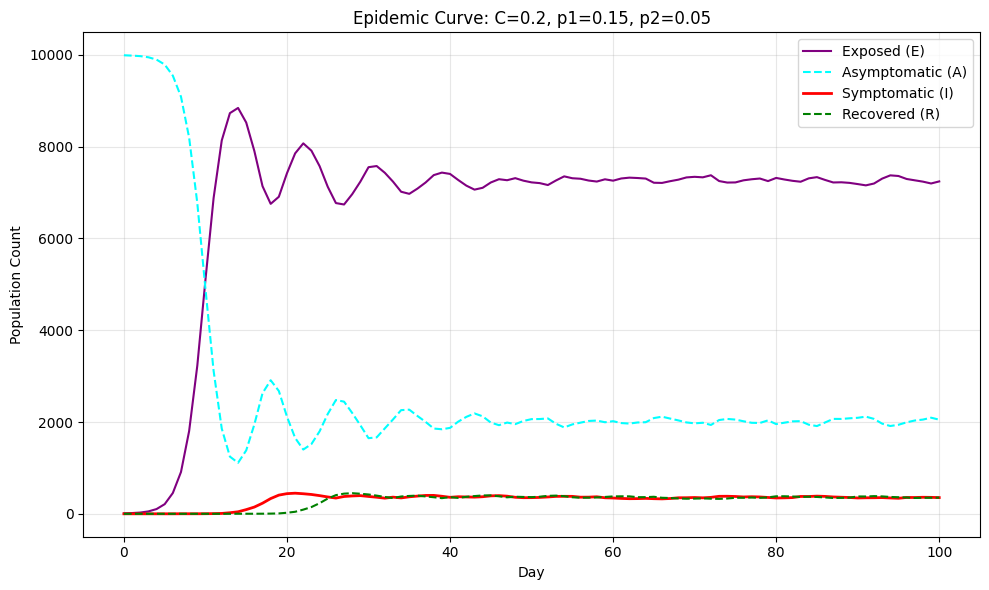

Loading C_0.2/p1_0.25_p2_0.2 …


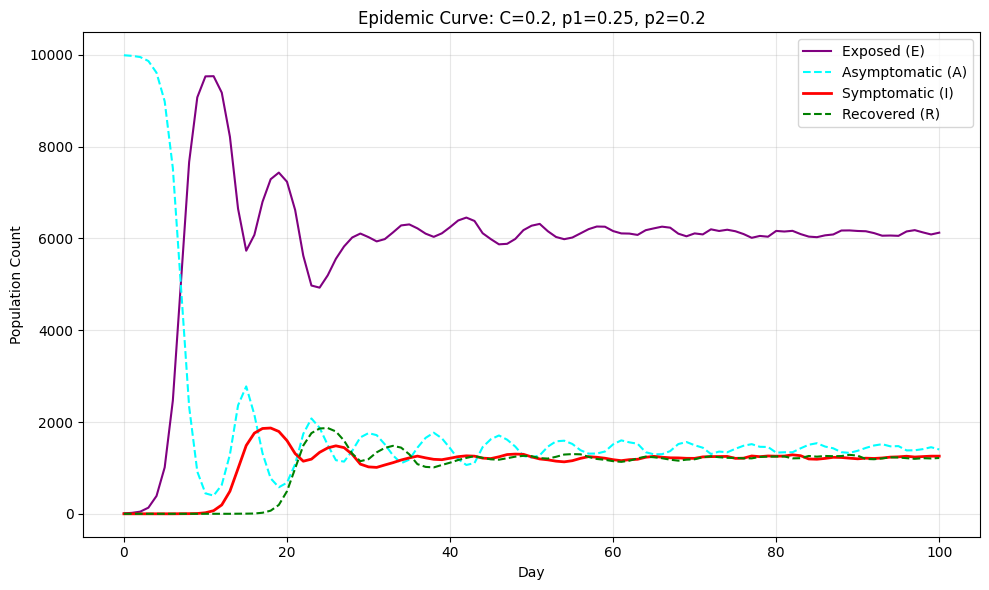

Loading C_0.2/p1_0.12_p2_0.05 …


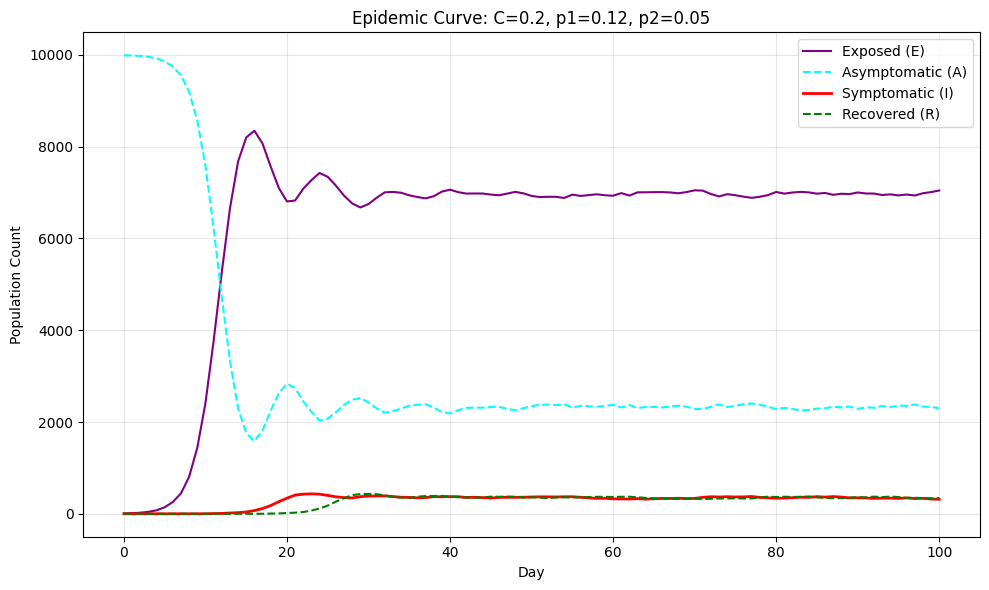

In [ ]:
# ============================================================
# EPIDEMIC CURVES  (unchanged logic)
# ============================================================
p_pairs = [
    (0.15, 0.05), (0.25, 0.2), (0.12, 0.05)
]
# p_pairs = [
#     (0.2, 0.1), (0.2, 0.2), (0.2, 0.05),
#     (0.12, 0.1), (0.12, 0.2), (0.12, 0.05),
#     (0.15, 0.1), (0.15, 0.2), (0.15, 0.05),
#     (0.25, 0.1), (0.25, 0.2),
# ]

for p1, p2 in p_pairs:
    base_path = f'C_0.2/p1_{p1}_p2_{p2}'
    print(f"Loading {base_path} …")
    df_status = pd.read_csv(f'{base_path}/individual_day_state.csv')
    df_gt     = df_status.groupby(['day', 'state']).size().unstack(fill_value=0).reset_index()
    t         = np.arange(101)
    plt.figure(figsize=(10, 6))
    plt.plot(t, df_gt[1], label='Exposed (E)',       color='purple')
    plt.plot(t, df_gt[0], label='Asymptomatic (A)',  color='cyan',  linestyle='--')
    plt.plot(t, df_gt[2], label='Symptomatic (I)',   color='red',   linewidth=2)
    plt.plot(t, df_gt[3], label='Recovered (R)',     color='green', linestyle='--')
    plt.title(f"Epidemic Curve: C=0.2, p1={p1}, p2={p2}")
    plt.xlabel("Day");  plt.ylabel("Population Count")
    plt.grid(True, alpha=0.3);  plt.legend();  plt.tight_layout()
    plt.savefig(f"p1_{p1}_p2_{p2}_epidemic_curve.png")
    plt.show()
    plt.close()

Starting Rolling Prediction with Continuous Calibration (Optimised)…


Case: C=0.2, p1=0.15, p2=0.05  |  loading C_0.2/p1_0.15_p2_0.05
  Day  25 | p1=0.1500 (true=0.15) | p2=0.0500 (true=0.05)
  Day  30 | p1=0.1500 (true=0.15) | p2=0.0500 (true=0.05)
  Day  35 | p1=0.1500 (true=0.15) | p2=0.0500 (true=0.05)
  Day  40 | p1=0.1500 (true=0.15) | p2=0.0500 (true=0.05)
  Day  45 | p1=0.1500 (true=0.15) | p2=0.0500 (true=0.05)
  Day  50 | p1=0.1500 (true=0.15) | p2=0.0500 (true=0.05)
  Day  55 | p1=0.1500 (true=0.15) | p2=0.0500 (true=0.05)
  Day  60 | p1=0.1500 (true=0.15) | p2=0.0500 (true=0.05)
  Day  65 | p1=0.1499 (true=0.15) | p2=0.0500 (true=0.05)
  Day  70 | p1=0.1499 (true=0.15) | p2=0.0500 (true=0.05)
  Day  75 | p1=0.1499 (true=0.15) | p2=0.0500 (true=0.05)
  Day  80 | p1=0.1499 (true=0.15) | p2=0.0500 (true=0.05)
  Day  85 | p1=0.1499 (true=0.15) | p2=0.0500 (true=0.05)
  Day  90 | p1=0.1499 (true=0.15) | p2=0.0500 (true=0.05)
  Day  95 | p1=0.1499 (true=0.15) | p2=0.0500 (true=0

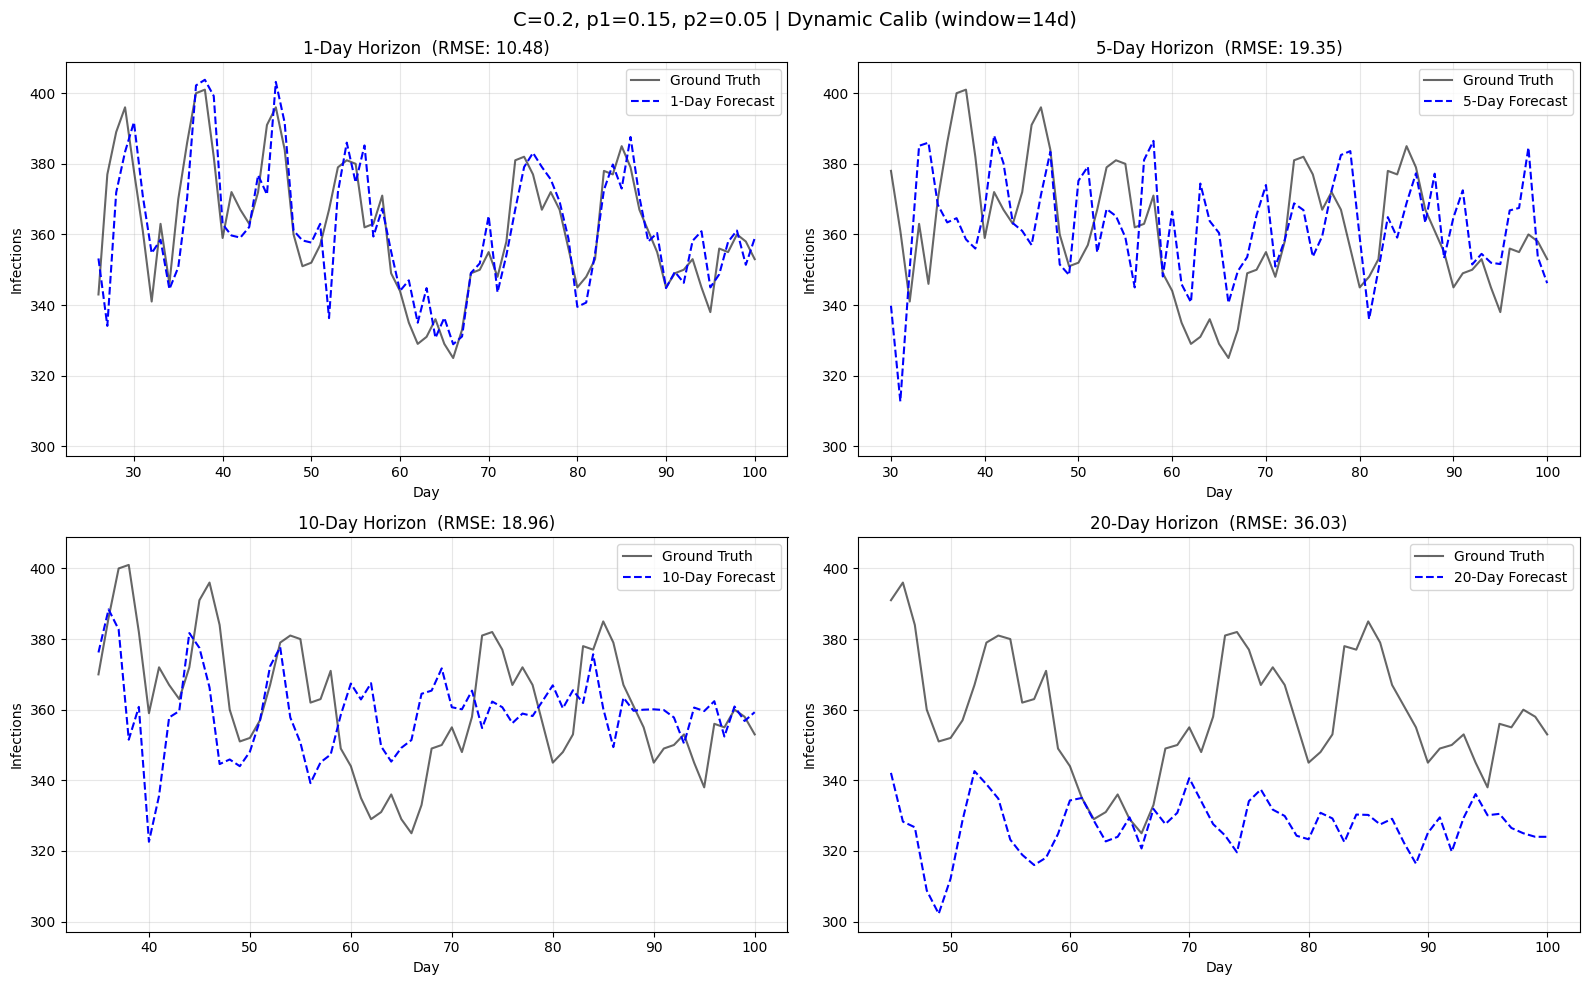

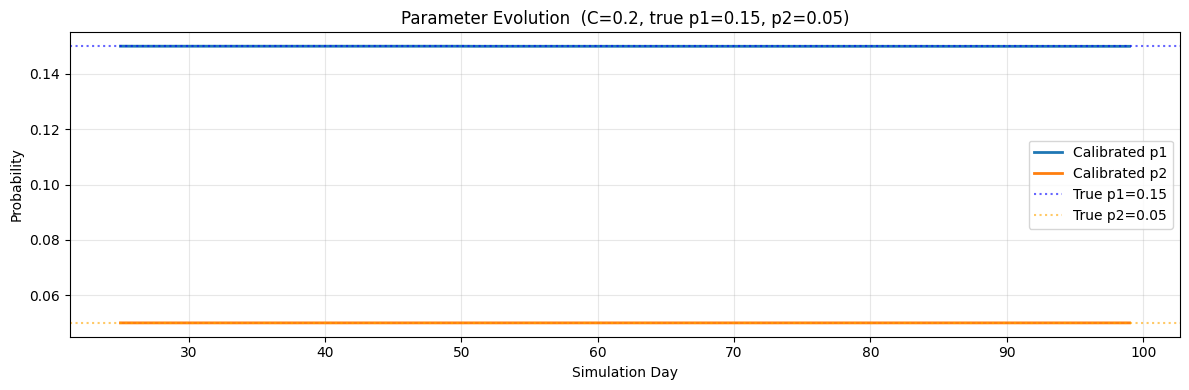


Case: C=0.2, p1=0.25, p2=0.2  |  loading C_0.2/p1_0.25_p2_0.2
  Day  25 | p1=0.2499 (true=0.25) | p2=0.2000 (true=0.2)
  Day  30 | p1=0.2495 (true=0.25) | p2=0.1999 (true=0.2)
  Day  35 | p1=0.2485 (true=0.25) | p2=0.1997 (true=0.2)
  Day  40 | p1=0.2480 (true=0.25) | p2=0.1996 (true=0.2)
  Day  45 | p1=0.2477 (true=0.25) | p2=0.1996 (true=0.2)
  Day  50 | p1=0.2477 (true=0.25) | p2=0.1996 (true=0.2)
  Day  55 | p1=0.2477 (true=0.25) | p2=0.1996 (true=0.2)
  Day  60 | p1=0.2476 (true=0.25) | p2=0.1996 (true=0.2)
  Day  65 | p1=0.2476 (true=0.25) | p2=0.1996 (true=0.2)
  Day  70 | p1=0.2476 (true=0.25) | p2=0.1996 (true=0.2)
  Day  75 | p1=0.2476 (true=0.25) | p2=0.1996 (true=0.2)
  Day  80 | p1=0.2475 (true=0.25) | p2=0.1996 (true=0.2)
  Day  85 | p1=0.2475 (true=0.25) | p2=0.1996 (true=0.2)
  Day  90 | p1=0.2475 (true=0.25) | p2=0.1996 (true=0.2)
  Day  95 | p1=0.2475 (true=0.25) | p2=0.1996 (true=0.2)


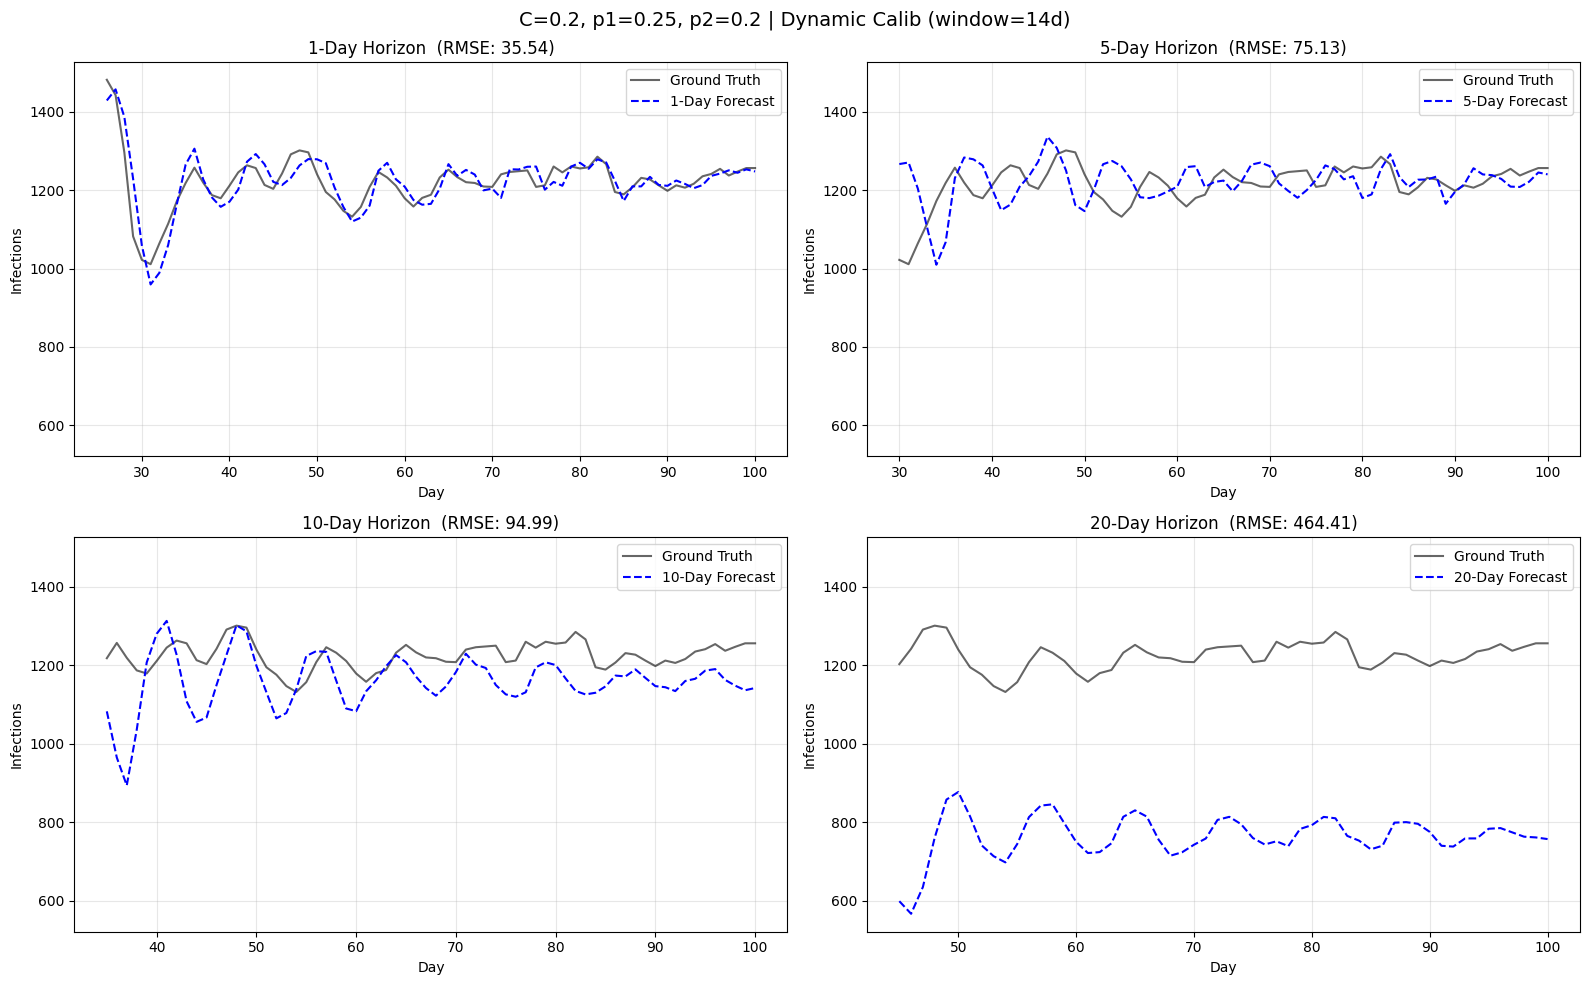

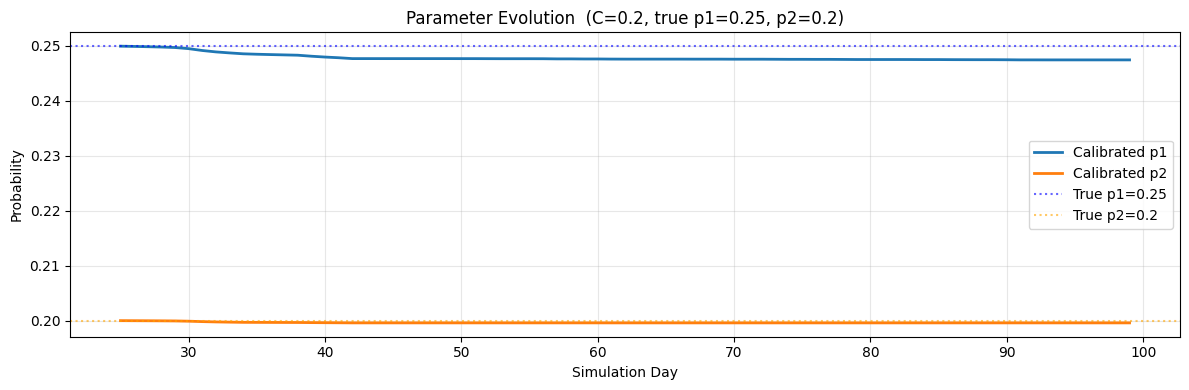


Case: C=0.2, p1=0.12, p2=0.05  |  loading C_0.2/p1_0.12_p2_0.05
  Day  25 | p1=0.1200 (true=0.12) | p2=0.0500 (true=0.05)
  Day  30 | p1=0.1200 (true=0.12) | p2=0.0500 (true=0.05)
  Day  35 | p1=0.1200 (true=0.12) | p2=0.0500 (true=0.05)
  Day  40 | p1=0.1200 (true=0.12) | p2=0.0500 (true=0.05)
  Day  45 | p1=0.1200 (true=0.12) | p2=0.0500 (true=0.05)
  Day  50 | p1=0.1200 (true=0.12) | p2=0.0500 (true=0.05)
  Day  55 | p1=0.1200 (true=0.12) | p2=0.0500 (true=0.05)
  Day  60 | p1=0.1200 (true=0.12) | p2=0.0500 (true=0.05)
  Day  65 | p1=0.1200 (true=0.12) | p2=0.0500 (true=0.05)
  Day  70 | p1=0.1200 (true=0.12) | p2=0.0500 (true=0.05)
  Day  75 | p1=0.1200 (true=0.12) | p2=0.0500 (true=0.05)
  Day  80 | p1=0.1200 (true=0.12) | p2=0.0500 (true=0.05)
  Day  85 | p1=0.1200 (true=0.12) | p2=0.0500 (true=0.05)
  Day  90 | p1=0.1200 (true=0.12) | p2=0.0500 (true=0.05)
  Day  95 | p1=0.1200 (true=0.12) | p2=0.0500 (true=0.05)


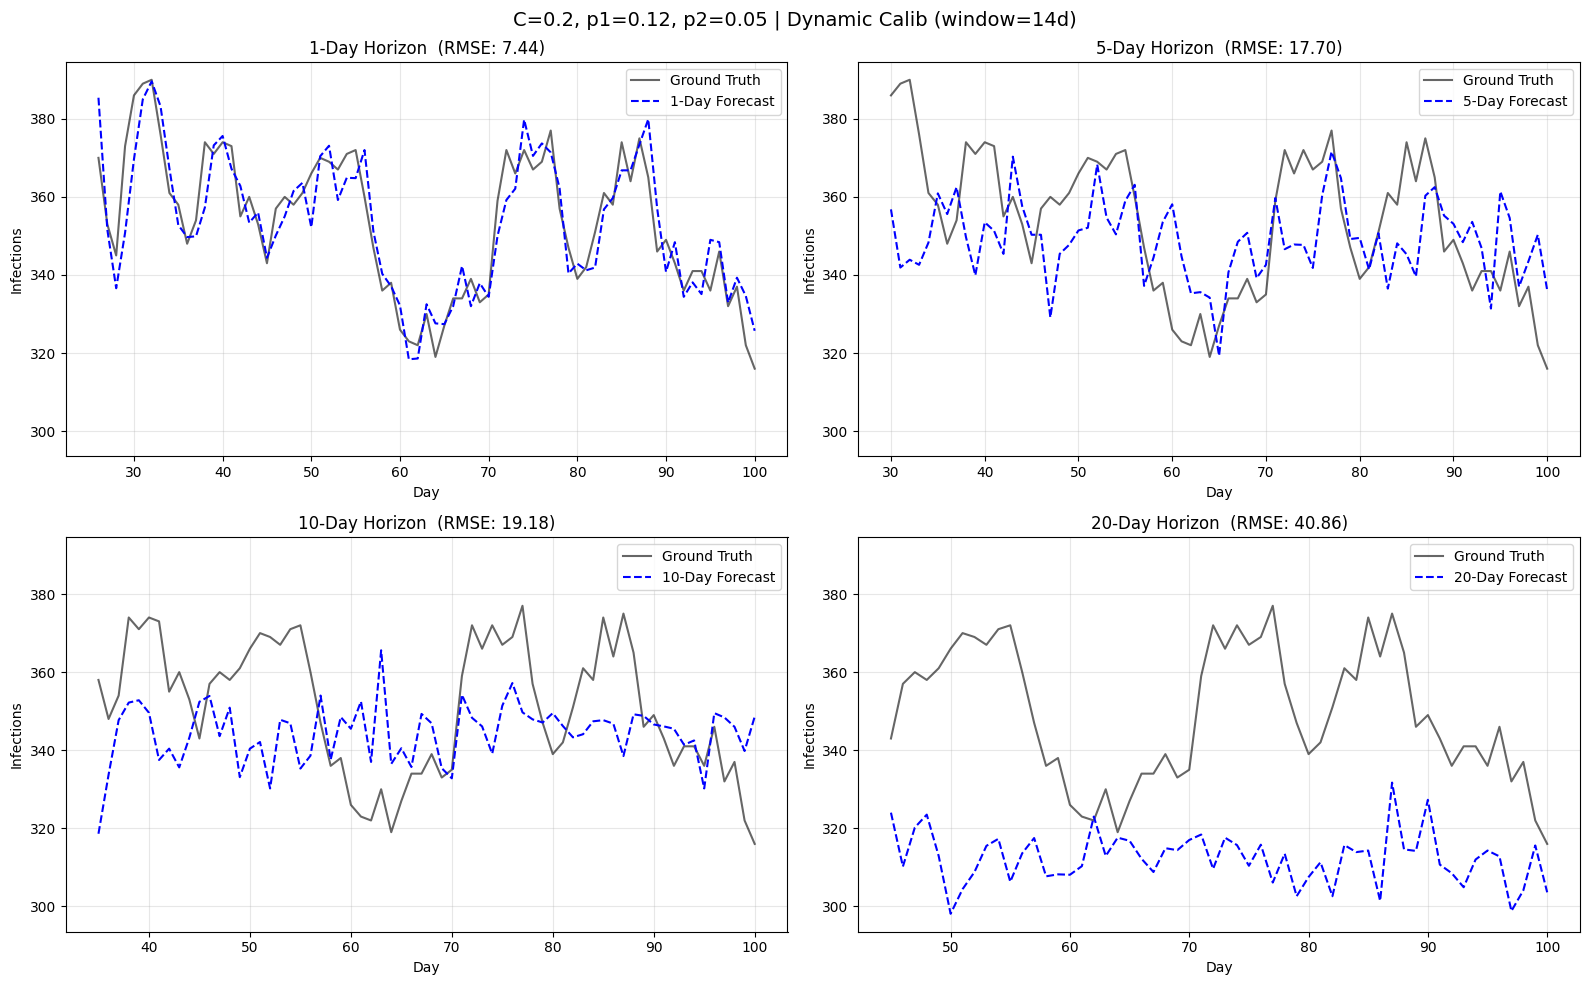

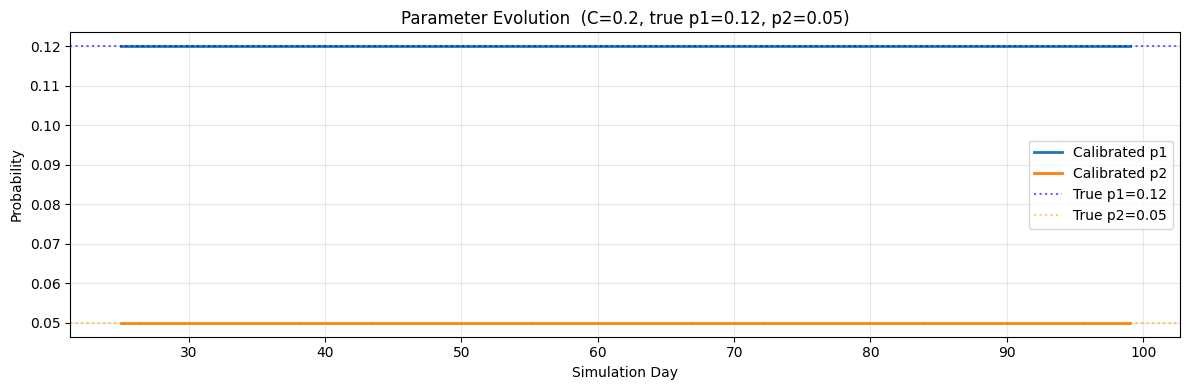

In [ ]:
# ============================================================
# SETUP & MAIN EXECUTION LOOP  —  OPTIMISED
# ============================================================

# --- Configuration ---
horizons         = [1, 5, 10, 20]
start_eval       = 25
max_day          = 100
total_population = 10000
calib_window     = 14       # calibration look-back window (days)
num_simulations  = 10       # Monte-Carlo runs per prediction step
damp_factor      = 0.01     # max per-day parameter shift (used in fixed formula)

print("Starting Rolling Prediction with Continuous Calibration (Optimised)…\n")

for p1_true, p2_true in p_pairs:
    base_path = f'C_0.2/p1_{p1_true}_p2_{p2_true}'
    print(f"\n{'='*60}")
    print(f"Case: C=0.2, p1={p1_true}, p2={p2_true}  |  loading {base_path}")
    print('='*60)

    try:
        df_status   = pd.read_csv(f'{base_path}/individual_day_state.csv')
        df_contacts = pd.read_csv(f'{base_path}/timed_edges.csv')
    except FileNotFoundError:
        raise FileNotFoundError(f"Data files not found at {base_path}. Check paths.")

    # ---- Ground truth ----
    df_gt = df_status.groupby(['day', 'state']).size().unstack(fill_value=0).reset_index()
    if 2 not in df_gt.columns: df_gt[2] = 0
    ground_truth_dict = dict(zip(df_gt['day'], df_gt[2]))

    # ---- State sets ----
    all_days  = sorted(df_status['day'].unique())
    state_sets = {}
    for d in all_days:
        day_data   = df_status[df_status['day'] == d]
        state_sets[d] = {
            'asymptomatic': set(day_data[day_data['state'] == 0]['id']),
            'infected':     set(day_data[day_data['state'] == 2]['id']),
            'recovered':    set(day_data[day_data['state'] == 3]['id']),
        }

    # ---- New-cohort history from ground truth ----
    global_new_asymp: dict = {}
    global_new_inf:   dict = {}
    for d in all_days:
        curr_A = state_sets[d]['asymptomatic']
        curr_I = state_sets[d]['infected']
        if d == 0:
            global_new_asymp[0] = curr_A
            global_new_inf[0]   = curr_I
        else:
            global_new_asymp[d] = curr_A - state_sets[d - 1]['asymptomatic']
            global_new_inf[d]   = curr_I - state_sets[d - 1]['infected']

    # ---- Master contacts dict ----
    master_contacts: dict = {}
    for day, group in df_contacts.groupby('day'):
        master_contacts[day] = list(zip(group['i'], group['j']))

    # ============================================================
    # OPTIMISATION 1: Build ONE model for the entire case.
    #
    # Previously: EpiInferContactRolling was re-instantiated every
    # iteration (once for calibration + 10× for MC = 11/day × 75
    # days = 825 constructions, each scanning the full contact list).
    #
    # Now: a single instance is built here with the FULL contact
    # history.  _get_contacts() already caps future-day lookups at
    # max_contact_day (see EpiInferContact._get_contacts), so
    # causality is preserved without slicing the dict each iteration.
    # ============================================================
    population_ids = list(range(total_population))
    model = EpiInferContactRolling(population_ids, master_contacts, 7, 7)

    recovered_sets_map = {d: state_sets[d]['recovered'] for d in state_sets}

    # ---- Rolling loop ----
    rows          = []
    current_p1    = p1_true   # starting guess = true value
    current_p2    = p2_true
    calib_history = []

    for current_day in range(start_eval, max_day):

        # ---- Calibration training data (14-day window) ----
        calib_start = max(0, current_day - calib_window)
        calib_training = {
            d: ground_truth_dict.get(d, 0)
            for d in range(calib_start, current_day + 1)
        }

        # ---- Run calibration (reuses model) ----
        best_p1, best_p2 = model.continuous_calibrate(
            training_data        = calib_training,
            training_days_window = calib_window,
            full_history_asymp   = global_new_asymp,
            full_history_inf     = global_new_inf,
            full_recovered_sets  = recovered_sets_map,
            current_day          = current_day,
            prev_p1              = current_p1,
            prev_p2              = current_p2,
            dampening_factor     = damp_factor,
        )
        current_p1 = best_p1
        current_p2 = best_p2
        calib_history.append({'day': current_day, 'p1': best_p1, 'p2': best_p2})

        # ---- History buffers for prediction (ground truth up to now) ----
        lookback = 8   # inc=7 + 1 buffer
        h_asymp  = {k: global_new_asymp[k] for k in range(current_day - lookback, current_day + 1)
                    if k in global_new_asymp}
        h_inf    = {k: global_new_inf[k]   for k in range(current_day - lookback, current_day + 1)
                    if k in global_new_inf}
        seed_rec = state_sets[current_day]['recovered']

        max_h        = max(horizons)
        end_pred_day = min(current_day + max_h + 1, max_day)

        # ---- Monte-Carlo forecast (reuses same model) ----
        aggregated: dict[int, float] = {}
        for _ in range(num_simulations):
            res = model.contact_infer_core_with_history(
                best_p1, best_p2, h_asymp, h_inf, current_day, end_pred_day, seed_rec)
            for d_target, val in res.items():
                aggregated[d_target] = aggregated.get(d_target, 0.0) + val

        averaged = {k: v / num_simulations for k, v in aggregated.items()}

        for h in horizons:
            tgt = current_day + h
            if tgt in averaged:
                rows.append({
                    'horizon':     h,
                    'current_day': current_day,
                    'target_day':  tgt,
                    'predicted':   averaged[tgt],
                    'actual':      ground_truth_dict.get(tgt, 0),
                    'p1_used':     best_p1,
                    'p2_used':     best_p2,
                })

        if current_day % 5 == 0:
            print(f"  Day {current_day:3d} | p1={best_p1:.4f} (true={p1_true}) "
                  f"| p2={best_p2:.4f} (true={p2_true})")

    df_res = pd.DataFrame(rows)

    # ============================================================
    # PLOTTING
    # ============================================================
    if df_res.empty:
        print("  No results generated.")
        continue

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    fig.suptitle(f'C=0.2, p1={p1_true}, p2={p2_true} | Dynamic Calib (window={calib_window}d)',
                 fontsize=14)

    all_actual    = df_res['actual'].values
    all_predicted = df_res['predicted'].values
    y_min = min(all_actual.min(), all_predicted.min())
    y_max = max(all_actual.max(), all_predicted.max())
    y_pad = 0.05 * (y_max - y_min)
    y_min -= y_pad;  y_max += y_pad

    for idx, h in enumerate(horizons):
        ax  = axes[idx]
        sub = df_res[df_res['horizon'] == h]
        if sub.empty: continue
        ax.plot(sub['target_day'], sub['actual'],    label='Ground Truth',     color='black', alpha=0.6)
        ax.plot(sub['target_day'], sub['predicted'], label=f'{h}-Day Forecast',color='blue',  linestyle='--')
        rmse = np.sqrt(((sub['predicted'] - sub['actual']) ** 2).mean())
        ax.set_title(f"{h}-Day Horizon  (RMSE: {rmse:.2f})")
        ax.legend();  ax.set_ylim(y_min, y_max)
        ax.set_xlabel("Day");  ax.set_ylabel("Infections")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"forecast_p1_{p1_true}_p2_{p2_true}.png")
    plt.show()

    # Parameter evolution
    df_params = pd.DataFrame(calib_history)
    plt.figure(figsize=(12, 4))
    plt.plot(df_params['day'], df_params['p1'], label='Calibrated p1', linewidth=2)
    plt.plot(df_params['day'], df_params['p2'], label='Calibrated p2', linewidth=2)
    plt.axhline(p1_true, color='blue',  linestyle=':', alpha=0.6, label=f'True p1={p1_true}')
    plt.axhline(p2_true, color='orange',linestyle=':', alpha=0.6, label=f'True p2={p2_true}')
    plt.title(f"Parameter Evolution  (C=0.2, true p1={p1_true}, p2={p2_true})")
    plt.xlabel("Simulation Day");  plt.ylabel("Probability")
    plt.legend();  plt.grid(True, alpha=0.3);  plt.tight_layout()
    plt.savefig(f"params_p1_{p1_true}_p2_{p2_true}.png")
    plt.show()